# Exploratory Analysis of Clinical Risk Factors in Diabetes Using Python

This project explores a clinical diabetes dataset to identify which variables show the strongest association with diabetes outcome. The analysis includes data cleaning, grouped comparison, correlation analysis, and visualisation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading and Initial Inspection

In [5]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data Cleaning

Several variables in this dataset contain zero values that are not physiologically plausible and are likely to represent missing data. These values were replaced with missing values and imputed using the median before analysis.

In [7]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols] = data[cols].replace(0, np.nan)
data.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
data.fillna(data.median(), inplace=True)
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 3. Group Comparison by Outcome

In [9]:
grouped = data.groupby("Outcome")[["Glucose", "BMI", "Age", "Insulin"]].mean()
grouped

,Glucose,BMI,Age,Insulin
Outcome,,,,
0,110.682000,30.885600,31.190000,127.792000
1,142.130597,35.383582,37.067164,164.701493


In [ ]:
grouped[["Glucose", "BMI", "Age"]]

,Glucose,BMI,Age
Outcome,,,
0,110.682000,30.885600,31.190000
1,142.130597,35.383582,37.067164


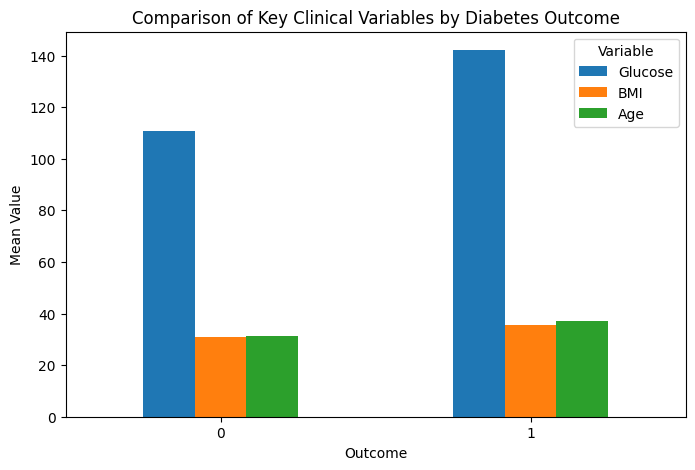

In [10]:
grouped[["Glucose", "BMI", "Age"]].plot(kind="bar", figsize=(8,5))
plt.title("Comparison of Key Clinical Variables by Diabetes Outcome")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Variable")
plt.show()

The grouped comparison shows that individuals with diabetes had higher average glucose, BMI, and age values than those without diabetes. Among these variables, glucose appears to show the clearest difference between the two groups.

## 4. Correlation Analysis

To better understand relationships between the clinical variables, a correlation matrix was generated. This helps identify which features appear most strongly associated with diabetes outcome.

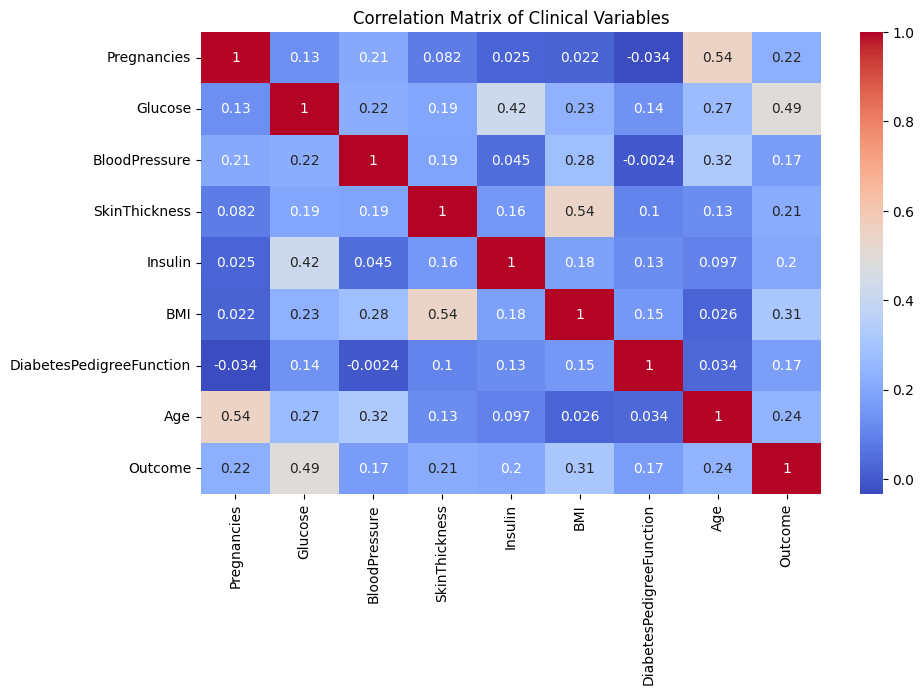

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Clinical Variables")
plt.show()

The correlation matrix shows that Glucose has the strongest association with diabetes outcome in this dataset (r = 0.49). BMI shows a moderate association (r = 0.31), while Age shows a weaker but still relevant relationship (r = 0.24). These findings support focusing on Glucose, BMI, and Age in the subsequent visual analysis.

## 5. Visualisation of Key Variables

To explore group differences more clearly, boxplots were used to compare the distribution of key clinical variables across diabetes outcome groups.

### Boxplot for Glucose

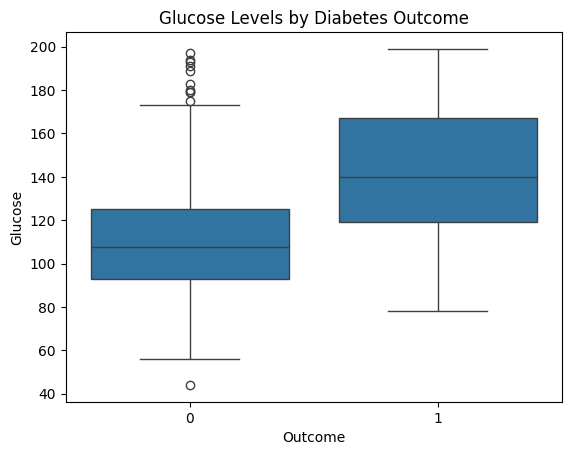

In [12]:
sns.boxplot(x="Outcome", y="Glucose", data=data)
plt.title("Glucose Levels by Diabetes Outcome")
plt.show()

### Boxplot for BMI

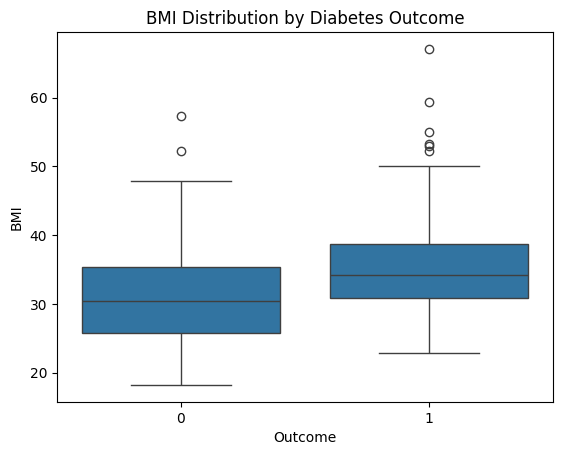

In [13]:
sns.boxplot(x="Outcome", y="BMI", data=data)
plt.title("BMI Distribution by Diabetes Outcome")
plt.show()

### Boxplot for Age

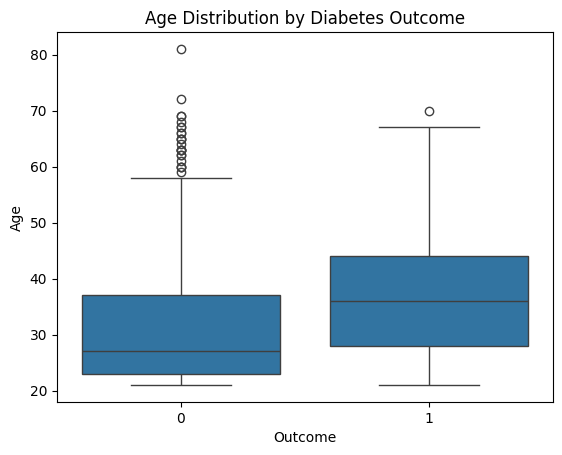

In [14]:
sns.boxplot(x="Outcome", y="Age", data=data)
plt.title("Age Distribution by Diabetes Outcome")
plt.show()

The boxplots reinforce the group comparison findings. Glucose levels are visibly higher in the diabetic group, while BMI and age also appear elevated compared with the non-diabetic group. These patterns suggest that glucose is the strongest differentiating variable in this dataset.

### Scatterplot: BMI and Glucose by Diabetes Outcome

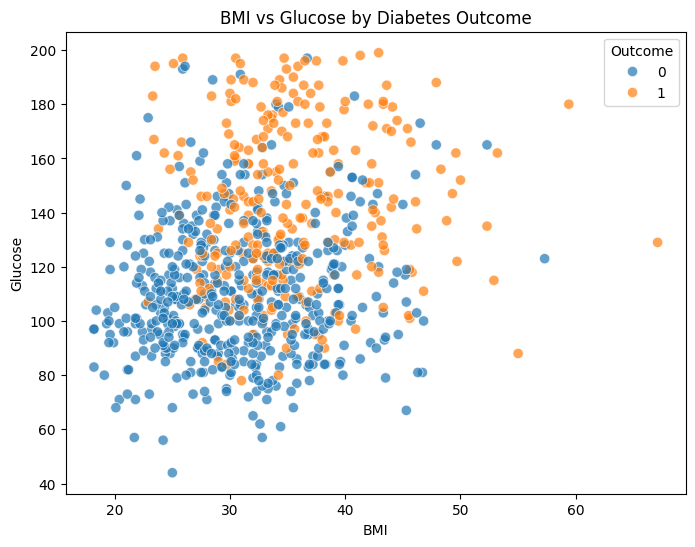

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="BMI", y="Glucose", hue="Outcome", data=data, alpha=0.7, s=55)
plt.title("BMI vs Glucose by Diabetes Outcome")
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.show()

The scatterplot shows substantial overlap between the two groups, but individuals with diabetes appear more frequently in the higher glucose range. BMI also varies across both groups, suggesting that while BMI may contribute to the clinical pattern, glucose is the stronger differentiating variable in this dataset.

## 6. Key Findings


- Glucose showed the strongest difference between diabetic and non-diabetic groups in this dataset.
- BMI and age were also higher on average in the diabetic group, suggesting moderate associations with diabetes outcome.
- The scatterplot showed substantial overlap between groups, indicating that BMI alone does not clearly separate diabetic and non-diabetic individuals.
- Several clinical variables contained implausible zero values, making data cleaning an important step before interpretation.
- This project demonstrated how data cleaning, grouped comparison, correlation analysis, and visualisation can be used to interpret real-world clinical data.





